In [2]:
# import libraries
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3

In [3]:
conn = sqlite3.connect('customer_churn.db')

sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table'

 """

tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn)
    globals()[f"df_{table_name}"] = df
    print(f"Created dataframe: df_{table_name}")

conn.close()    

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [13]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()    


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


In [ ]:
# data cleaning

In [14]:
# df_db_customer.head()
df_db_customer.tail()

,customerid,name,country,state,gender,dob,interests,pincode
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19 00:00:00,NaN,None
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02 00:00:00,NaN,None
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30 00:00:00,NaN,None
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Men,1991-05-14 00:00:00,NaN,None
20,0023-UYUPN,sudevi,India,Maharashtra,Women,1977-10-06 00:00:00,NaN,None


In [15]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     str   
 1   name        21 non-null     str   
 2   country     18 non-null     str   
 3   state       21 non-null     str   
 4   gender      21 non-null     str   
 5   dob         21 non-null     str   
 6   interests   4 non-null      str   
 7   pincode     0 non-null      object
dtypes: object(1), str(7)
memory usage: 1.4+ KB


In [ ]:
# a. rename col - name
# b. drop columns - intrest and pincode
# c. change data type - dob
# d. data standardization - gernder
# e. fix missing values -country

In [16]:
# a. rename col - name

df_db_customer.rename(columns = {'name' : 'customer_name'}, inplace= True)

In [17]:
# b. drop columns - intrest and pincode

#df_db_customer.drop(df_db_customer.columns[-2:])
#df_db_customer.drop(df_db_customer.columns[-2:], axis=1)
#df_db_customer.columns[6:]

df_db_customer.drop(columns=['interests', 'pincode'], inplace=True)

In [18]:
df_db_customer.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   customerid     21 non-null     str  
 1   customer_name  21 non-null     str  
 2   country        18 non-null     str  
 3   state          21 non-null     str  
 4   gender         21 non-null     str  
 5   dob            21 non-null     str  
dtypes: str(6)
memory usage: 1.1 KB


In [19]:
# c. change data type - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])

In [20]:
# d. data standardization - gernder

#df_db_customer['gender'].unique()
df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male' ,'Women' : 'Female'})

In [21]:
df_db_customer['gender'].unique()

<StringArray>
['Male', 'Female']
Length: 2, dtype: str

In [22]:
# e. fix missing values -country

df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,NaN,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,NaN,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,NaN,Telangana,Female,2004-12-01


In [23]:
# country and state - uniqe value pair

#df_db_customer[['country' , 'state']]

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()
df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))

In [24]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [25]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [26]:
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customerid               21 non-null     str    
 1   subscription_start_date  21 non-null     str    
 2   subscription_type        21 non-null     str    
 3   renewal_date             21 non-null     str    
 4   plan_type                21 non-null     str    
 5   contract_type            21 non-null     str    
 6   cancellation_date        6 non-null      str    
 7   cancellation_reason      6 non-null      str    
 8   monthly_charges          21 non-null     float64
 9   cltv                     21 non-null     int64  
 10  churn_score              21 non-null     int64  
dtypes: float64(1), int64(2), str(8)
memory usage: 1.9 KB


In [27]:
date_col = ['subscription_start_date', 'renewal_date']


df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)
df_db_subscription.info()

<class 'pandas.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     str           
 1   subscription_start_date  21 non-null     datetime64[us]
 2   subscription_type        21 non-null     str           
 3   renewal_date             21 non-null     datetime64[us]
 4   plan_type                21 non-null     str           
 5   contract_type            21 non-null     str           
 6   cancellation_date        6 non-null      str           
 7   cancellation_reason      6 non-null      str           
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[us](2), float64(1), int64(2), str(6)
memory usage: 1.9 KB


In [28]:
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [29]:
df_db_support.drop(columns=['col_1', 'comment'], inplace=True)

In [30]:
df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

df_db_support.info()

<class 'pandas.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      str           
 1   complaint_date  9 non-null      datetime64[us]
 2   escalations     9 non-null      str           
 3   csat_score      9 non-null      int64         
dtypes: datetime64[us](1), int64(1), str(2)
memory usage: 420.0 bytes


In [ ]:
# Feature Engineering and Data Analysis

In [31]:
# create a new col using existing col - churn flag
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(), 1, 0)

In [32]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaN,NaN,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaN,NaN,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaN,NaN,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [33]:
 # first fix support table duplicates then merge
df = (df_db_subscription
             .merge(df_db_customer, on = 'customerid', how= 'left')
             .merge(df_db_support, on = 'customerid', how= 'left'))

In [34]:
df_db_subscription.shape

(21, 12)

In [35]:
df.shape

(23, 20)

In [36]:
df_db_subscription['customerid'].nunique()

21

In [37]:
df_db_customer['customerid'].nunique()

21

In [38]:
df_db_support['customerid'].nunique()

7

In [39]:
df_db_support['customerid'].size

9

In [40]:
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [41]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [42]:
df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep= 'last')

In [43]:
df_db_support['customerid'].size

7

In [44]:
 # merge df
df = (df_db_subscription
             .merge(df_db_customer, on = 'customerid', how= 'left')
             .merge(df_db_support, on = 'customerid', how= 'left'))

In [45]:
df.shape

(21, 21)

In [46]:
df.to_csv('exported_churn_data.csv', index=False)

In [ ]:
# Data Analysis

In [ ]:
# 1. Churn Rate

In [47]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='str')

In [48]:
churn_rate = df['churn_flag'].mean()*100
print("Churn Rate = ", round(churn_rate,2),"%")

Churn Rate =  28.57 %


In [49]:
# 2. Retention Rate
retention_rate = 100- churn_rate
print("Retention Rate = ", round(retention_rate,2),"%")

Retention Rate =  71.43 %


In [50]:
# 3. Churn by Plan type
churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_ptc'))
print(churn_by_plan)

  plan_type  churn_rate_ptc
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [ ]:
# 4 a. Churn by state + sum(revenue ) & count of users -- home work **
# 4 b. Churn by subscription type + sum(revenue ) & count of users -- home work **

In [51]:
# 5. ARRU - Avg Revenue per user
arpu = df['monthly_charges'].mean()
print('ARPU =', round(arpu,2))

ARPU = 18.85


In [ ]:
# homework - calculate customer age

In [52]:
# Convert date columns into proper datetime format

df['subscription_start_date'] = pd.to_datetime(
    df['subscription_start_date'],
    errors='coerce'
)

df['cancellation_date'] = pd.to_datetime(
    df['cancellation_date'],
    errors='coerce'
)

In [53]:
# 6. Avg Customer Tenure
# count of days users has used our service : cancellation date else current date
today = pd.Timestamp.today()

df['tenure_days'] = np.where(
        df['cancellation_date'].notna(),

       
    (df['cancellation_date'] - df['subscription_start_date']).dt.days,

      (today - df['subscription_start_date']).dt.days 
)

avg_tenure = df['tenure_days'].mean()
print("Avg Tenure (Days) = ", round(avg_tenure),0)

Avg Tenure (Days) =  1527 0


In [54]:
# 7. Revenue at risk - revenue lost from churned users
revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print("Revenue at Risk (Rs 'k')=", revenue_at_risk)

Revenue at Risk (Rs 'k')= 73.94


In [55]:
# 8. Esclotion Rate
escalation_rate = (df['escalations']=='Y').mean()*100
print("Escalation Rate = ", round(escalation_rate, 2), "%")
#df['escalations'].unique()

Escalation Rate =  19.05 %


In [56]:
# 9. Avg Complaint Per User
avg_complaints = df['complaint_count'].sum() / df['customerid'].nunique()
print("Avg Complaints Per User = ", round(avg_complaints, 2))

Avg Complaints Per User =  0.43


In [86]:
# 10. Correlation Esclation vs Churn
df['escalations'] = np.where(df['escalations'] == 'Y', 1, 0) # encoding string to int type
corr_df = df[['escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df['churn_flag'])
print("Correlation between esclation vs churn is = ", round(correlation,2))


Correlation between esclation vs churn is =  0.77


In [58]:
# 11. create a column using existing col - churn risk 
conditions = [
        (df['churn_score'] < 50),
          (df['churn_score'] >= 50) & (df['churn_score'] < 70),
            (df['churn_score'] >= 70),
]

choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(conditions, choices, default='unkown')

In [ ]:
# 4. Visualization using Matplotlib

In [59]:
df_visual = df.copy()

In [60]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='str')

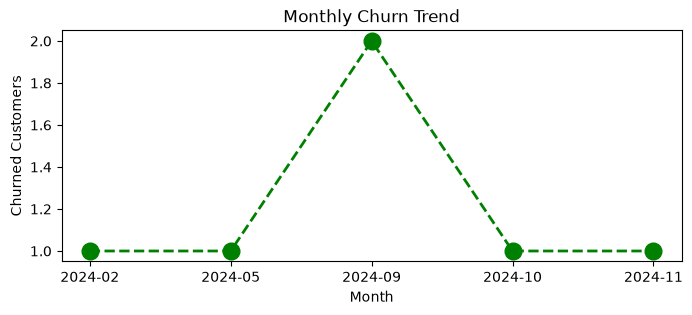

In [61]:
# 4.1 Monthly Churn Trend (Time Series KPI)

df_visual['cancellation_month'] = df_visual['cancellation_date'].dt.to_period('M')

churn_trend = df_visual[df_visual['churn_flag'] == 1].groupby('cancellation_month').size()

plt.figure(figsize=(8,3))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='green', marker='o', linestyle='dashed', linewidth=2, markersize=12)

plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.show()

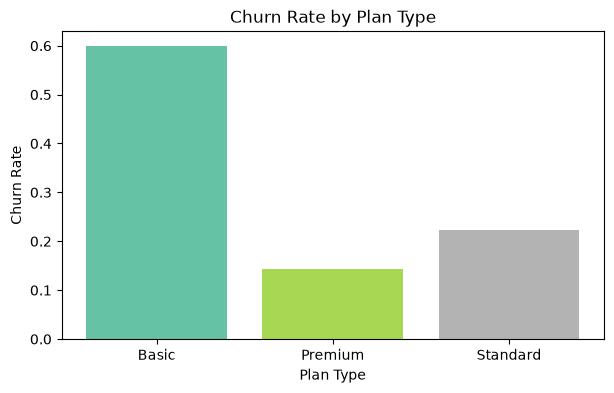

In [62]:
# 4.2 Churn by Plan type
churn_plan = df_visual.groupby('plan_type')['churn_flag'].mean()

#colors = ['yellow', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(7,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)

plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Plan Type')
plt.show()

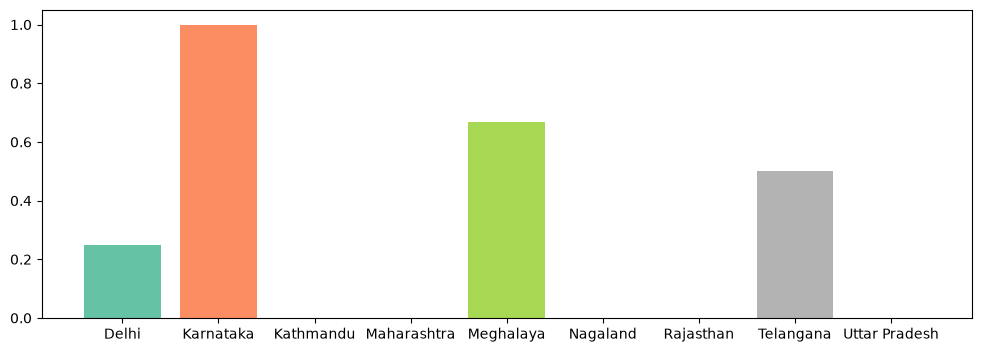

In [63]:
# 4.3 Churn by States
churn_plan = df_visual.groupby('state')['churn_flag'].mean()

#colors = ['yellow', 'blue']
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(12,4))

plt.bar(churn_plan.index, churn_plan.values, color = colors)
plt.show()


In [ ]:
# Visulaization using Seaborn

In [64]:
# encoding - convert str to numeric so that we can find corr between features
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

In [65]:
#df_encoded = 
df[['plan_type', 'contract_type', 'churn_score','churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,Y
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,Y


In [83]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,NaN
1,2,1,91,1,2,Y
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,Y


In [68]:
import warnings
warnings.filterwarnings("ignore")

In [69]:
# incorrect method of encoding - as numbers are not assigned based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'churn_risk', 'escalations']]

categorial_cols = ['plan_type', 'contract_type', 'churn_risk']

for col in categorial_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

<Axes: >

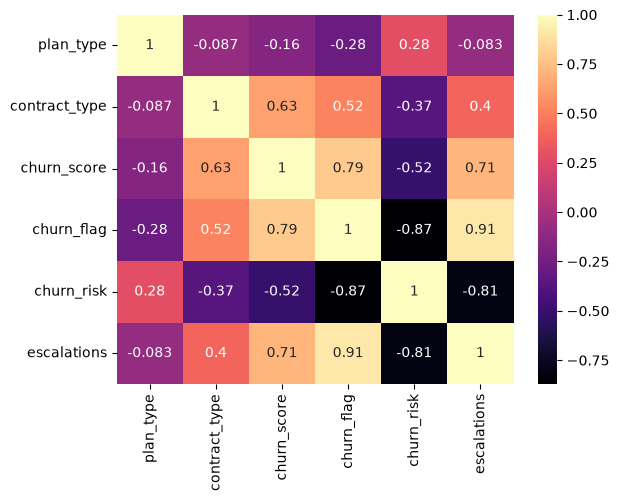

In [75]:
# Heatmap (correlation matrix)

#numeric_df = df_encoded.select_dtypes(include='number')
#plt.figure(figsize=(10,8))

#sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
#lt.title('Correlation Heatmap')
#plt.show()

#sns.heatmap(df_encoded.corr(numeric_only=True), annot=True)
sns.heatmap(df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk','escalations']].apply(lambda x: x.astype('category').cat.codes).corr(), annot=True, cmap='magma')

In [70]:
df_visual['plan_type'].unique()

<StringArray>
['Standard', 'Premium', 'Basic']
Length: 3, dtype: str

In [71]:
# Correct method of encoding - based on priority

df_encoded = df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'churn_risk', 'escalations']]

order_mappings = { 
    'plan_type' : ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low', 'med', 'high']
    }

for col, order in order_mappings.items():
    df_encoded[col] = pd.Categorical(df_encoded[col].astype('category'), categories=order, ordered=True).codes


In [72]:
df_visual[['plan_type', 'contract_type', 'churn_score','churn_flag', 'churn_risk', 'escalations']].head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,Standard,Annual,12,0,low,NaN
1,Premium,Annual,91,1,high,Y
2,Basic,Monthly,34,0,low,NaN
3,Premium,Annual,8,0,low,NaN
4,Standard,Monthly,88,1,high,Y


In [73]:
df_encoded.head()

,plan_type,contract_type,churn_score,churn_flag,churn_risk,escalations
0,1,1,12,0,0,NaN
1,2,1,91,1,2,Y
2,0,0,34,0,0,NaN
3,2,1,8,0,0,NaN
4,1,0,88,1,2,Y


<Axes: >

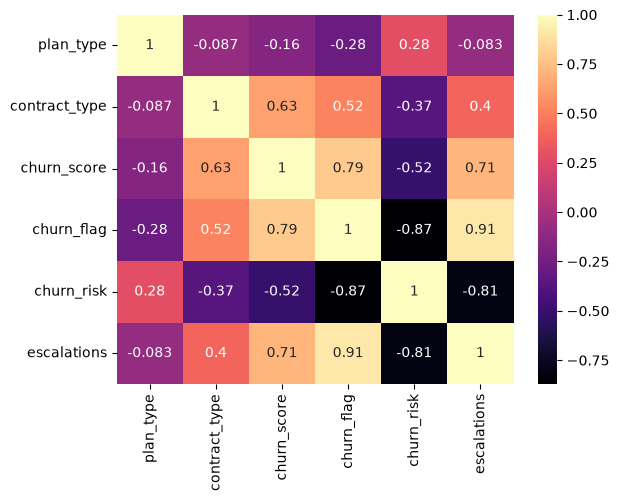

In [74]:
# sns.heatmap(df_encoded.corr(), annot=True)
sns.heatmap(df_visual[['plan_type', 'contract_type', 'churn_score', 'churn_flag', 'churn_risk','escalations']].apply(lambda x: x.astype('category').cat.codes).corr(), annot=True, cmap='magma')

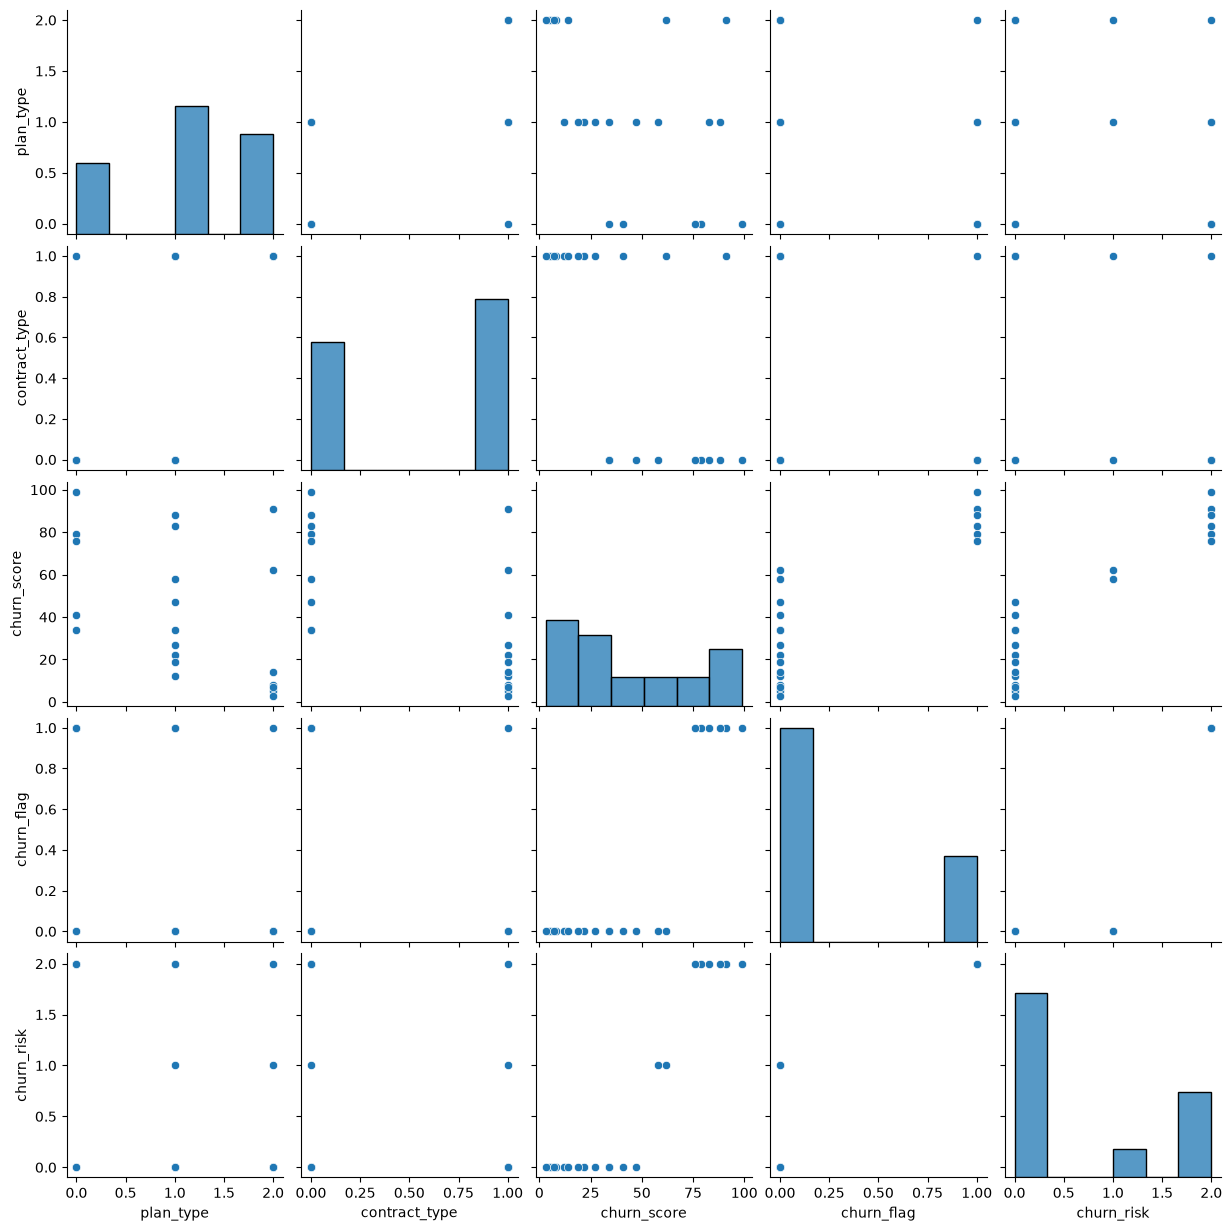

In [75]:
# pairplot - relationship in a dataset
sns.pairplot(df_encoded)

In [76]:
df_visual.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk', 'cancellation_month'],
      dtype='str')

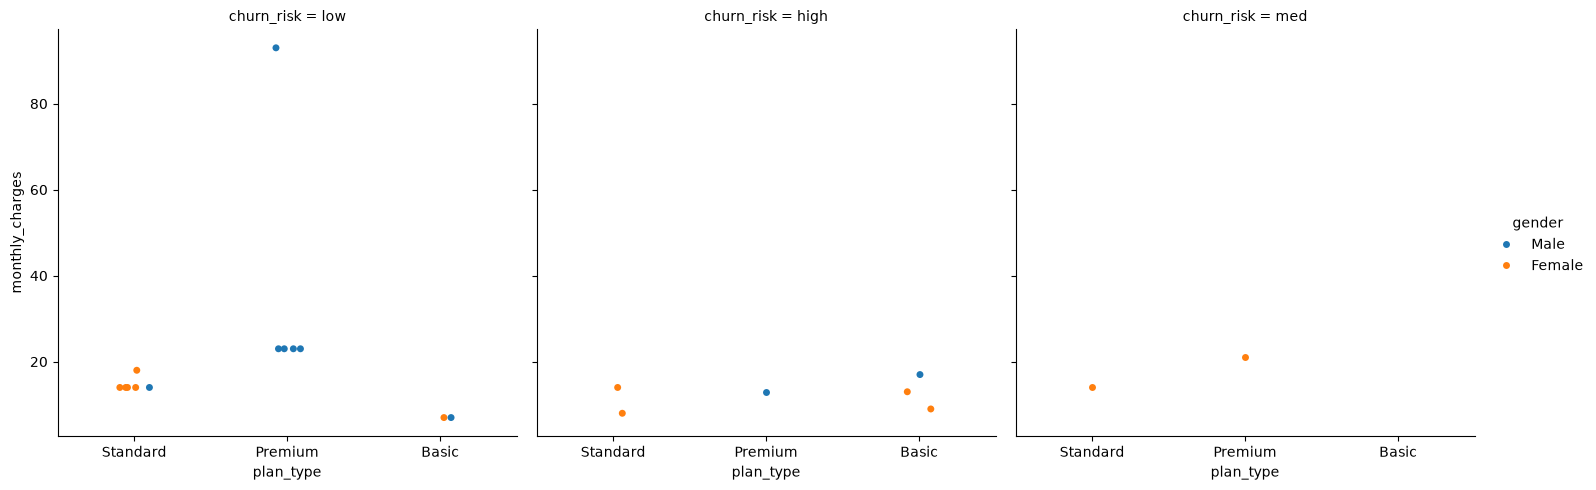

In [77]:
# catplt/Facegrid plot - multi-dim comparison

sns.catplot(data=df_visual,
    x='plan_type',
    y='monthly_charges',
    hue='gender',
    col='churn_risk')

In [ ]:
# Pivot Table

In [78]:
pd.pivot_table(
     df_visual,
     values='churn_flag',
     index='plan_type',
     aggfunc = 'mean'
).reset_index()

,plan_type,churn_flag
0,Basic,0.600000
1,Premium,0.142857
2,Standard,0.222222


In [82]:
pd.pivot_table(
     df_visual,
     index='plan_type',
     values=['monthly_charges', 'customerid', 'churn_flag'],
     aggfunc = { 
        'monthly_charges' : 'sum',
        'customerid' : 'nunique',
        'churn_flag' : 'mean'
       }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


In [ ]:
# Working with SQL in Python (pandas)

In [ ]:
# create db in sql
conn = sqlite3.connect('test_database.sqlite')

#table details
conn.execute(" " "CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)""")

#commit and save
conn.commit()

In [ ]:
# insert data

cursor = conn.cursor()

# write sql query to insert records in sql table
cursor.execute(
    """

         INSERT INTO users VALUES
         ('Mayank', 'India', 5000),
         ('Rishab', 'Germany', 2500),
         ('Vishal', 'India', 3500)
    """     
)

# commit and save
conn.commit()
print("Data Inserted successfully!")

Data Inserted successfully!


In [88]:
# check inserted data in table 
conn = sqlite3.connect('test_database.sqlite')
query = """SELECT * FROM users"""

df_results = pd.read_sql(query, conn)

df_results.head()

,first_name,country,budget
0,Mayank,india,5000
1,Rishab,Germany,2500
2,Vishal,India,3500


In [89]:
# aggregation
query = """ 
        SELECT country, sum(budget) as total_budget
        FROM users
        GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,2500
1,India,3500
2,india,5000


In [ ]:
# alwasy close the conn with db once the task is over
conn.close()


In [10]:
df.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment'],
      dtype='str')

In [ ]:
# df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [7]:
df.columns

Index(['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1',
       'comment'],
      dtype='str')

In [6]:
df.head(2)

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
